The Dose and NetOD data comes from my Matlab Filmcalibration script. I imported it here:

In [29]:
#Preamble
import pandas as pd
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

#Read in data
data = pd.read_excel("../Calibration data_finalfornow/Dose and OD data.xlsx")
Doses = data["Dose"].to_numpy()
netOD = data["Avg netOD"].to_numpy()

In [27]:
#Load function information that Matlab script stored
function_info = sio.loadmat("../Calibration data_finalfornow/Calibration_data.mat")
#The fitted parameters a and b
x = function_info["x"]
#The n
n = function_info["n"]

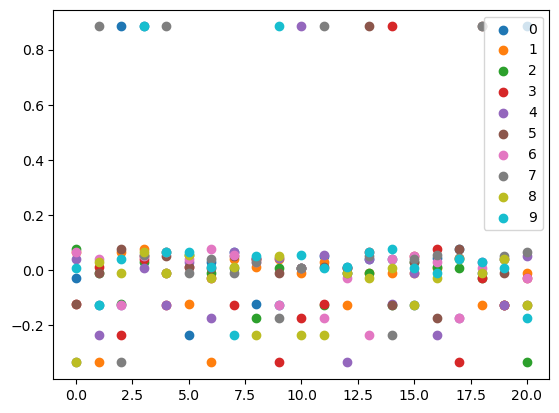

In [47]:
#Sample size
n_sample = len(Doses)
#number of bootstrap samples
n_bootstraps = 10

Residuals = np.zeros([n_bootstraps, n_sample])

for b in range(n_bootstraps):
    #Resample the data into a bootstrap sample (so with replacement)
    indices = np.random.randint(0,n_sample, n_sample) #randomly generate indexes
    Doses_b = Doses[indices]
    netOD_b = netOD[indices]

    Doses_b_prediction = x[0,0]*netOD_b + x[0,1]*np.power(netOD_b, n)

    Residuals[b,:] = Doses_b_prediction - Doses_b

    plt.scatter(np.arange(n_sample), Residuals[b,:],label=str(b))
plt.legend()

    